In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
from pathlib import Path
import sys
from PIL import Image

sys.path.insert(0, '/workspace/src')
from gaussvae.models.resnet_conv1d_vae import ResNetConv1DVAE

In [11]:
SAMPLE_IDS = ['img_000001', 'img_000002', 'img_000003', 'img_000004', 'img_000005']
MODEL_PATH = '/workspace/experiments/run_012_2048d_finetune/checkpoints/best'
DATA_DIR_DELAUNAY = Path('/workspace/data/delaunay')
DATA_DIR = Path('/workspace/data')
OUT_DIR = Path('/workspace/notebooks/outputs/10_minimal_run012')
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [12]:
vae = tf.keras.models.load_model(MODEL_PATH, custom_objects={'ResNetConv1DVAE': ResNetConv1DVAE}, compile=False)

stats = np.load(DATA_DIR / 'normalization_stats.npz')
mean = np.concatenate([stats['xy_mean'], stats['scale_mean'], 
                       stats['rot_mean'][None] if stats['rot_mean'].shape == () else stats['rot_mean'],
                       stats['feat_mean']])
std = np.concatenate([stats['xy_std'], stats['scale_std'],
                      stats['rot_std'][None] if stats['rot_std'].shape == () else stats['rot_std'],
                      stats['feat_std']])

In [13]:
# Count parameters in encoder and decoder
print("Model Parameter Counts:")
print("=" * 60)

total_params = vae.count_params()
print(f"Total parameters: {total_params:,}")

# Count encoder parameters
encoder_params = sum([tf.size(w).numpy() for w in vae.encoder.trainable_weights])
print(f"Encoder parameters: {encoder_params:,} ({encoder_params/total_params*100:.1f}%)")

# Count decoder parameters  
decoder_params = sum([tf.size(w).numpy() for w in vae.decoder.trainable_weights])
print(f"Decoder parameters: {decoder_params:,} ({decoder_params/total_params*100:.1f}%)")

# Verify sum
print(f"\nVerification: {encoder_params + decoder_params:,} (should equal {total_params:,})")
print("=" * 60)

Model Parameter Counts:
Total parameters: 54,207,063
Encoder parameters: 12,246,304 (22.6%)
Decoder parameters: 41,911,848 (77.3%)

Verification: 54,158,152 (should equal 54,207,063)


**Normalization verification:**

The preprocessing pipeline uses Z-score normalization:
- **Normalize (forward):** `normalized = (original - mean) / std`
- **Denormalize (reverse):** `original = normalized * std + mean`

This is standard practice - it's the inverse operation of normalization.

In [14]:
def create_checkpoint(gaussians, path):
    template = torch.load(DATA_DIR_DELAUNAY / 'checkpoints/train/checkpoints/img_000001.pt', map_location='cpu')
    checkpoint = {
        'state_dict': {
            'xy': torch.from_numpy(gaussians[:, 0:2]),
            'scale': torch.from_numpy(gaussians[:, 2:4]),
            'rot': torch.from_numpy(gaussians[:, 4:5]),
            'feat': torch.from_numpy(gaussians[:, 5:8]),
            'vis_feat': torch.zeros((512, 3), dtype=torch.float32)
        },
        **{k: template[k] for k in ['optim_state_dict', 'step', 'bytes', 'flip', 'lpips', 'msssim', 'psnr', 'ssim', 'time']}
    }
    torch.save(checkpoint, path)

def reconstruct(gaussians):
    normalized = (gaussians - mean) / std
    with tf.device('/CPU:0'):
        recon = vae.predict(normalized[np.newaxis, ...], verbose=0)[0]
    return recon * std + mean

In [15]:
mse_scores = {}
for sid in SAMPLE_IDS:
    data = np.load(DATA_DIR_DELAUNAY / f'npz/train/{sid}.npz')
    gaussians = data['gaussians']
    recon = reconstruct(gaussians)
    
    mse_scores[sid] = np.mean((gaussians - recon)**2)
    create_checkpoint(gaussians, OUT_DIR / f'{sid}.pt')
    create_checkpoint(recon, OUT_DIR / f'{sid}_vae.pt')

print(f"MSE: {np.mean(list(mse_scores.values())):.6f} ± {np.std(list(mse_scores.values())):.6f}")

MSE: 0.569479 ± 0.199334


**Render checkpoints (run in terminal):**
```bash
sudo chown -R $(whoami):$(whoami) notebooks/outputs/10_minimal_run012
echo "y" | python scripts/decode_gaussians.py --input notebooks/outputs/10_minimal_run012 --output notebooks/outputs/10_minimal_run012/renders_input --input_images data/delaunay/raw/train
echo "y" | python scripts/decode_gaussians.py --input notebooks/outputs/10_minimal_run012 --output notebooks/outputs/10_minimal_run012/renders_vae --input_images data/delaunay/raw/train
```

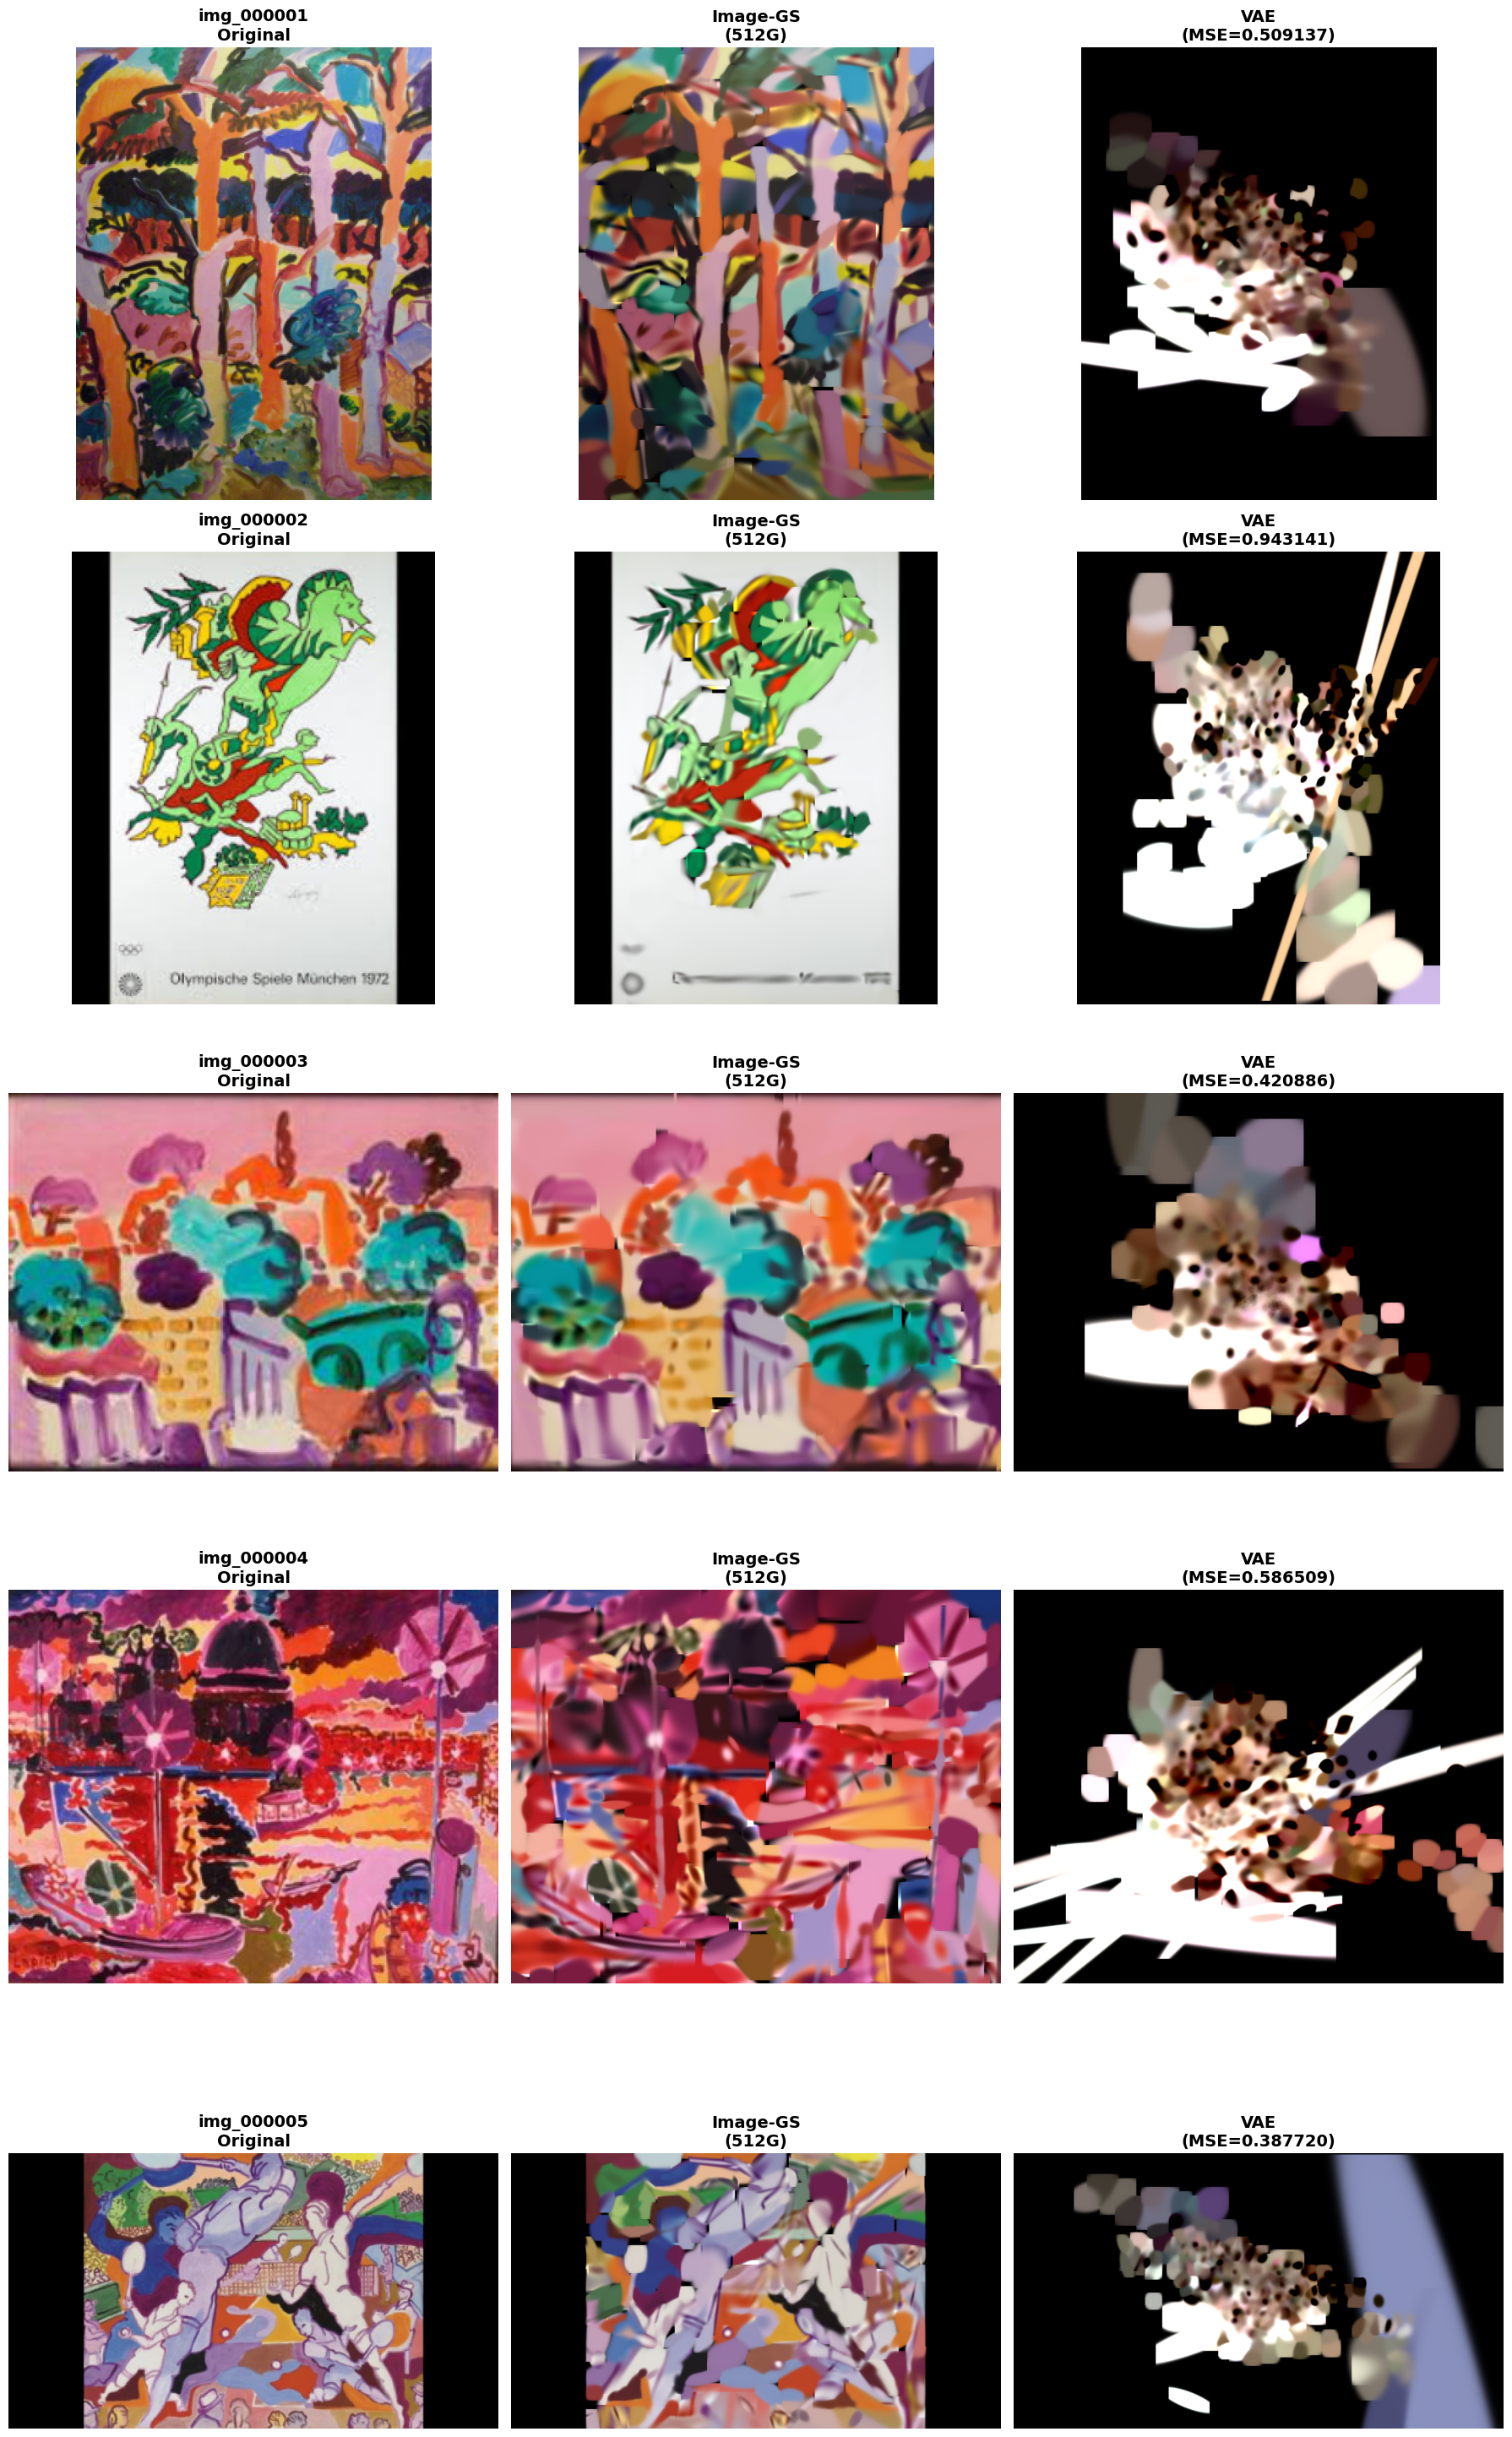

In [16]:
renders = {'input': OUT_DIR / 'renders_input/images', 'vae': OUT_DIR / 'renders_vae/images'}
valid = [s for s in SAMPLE_IDS if (renders['input'] / f'{s}.png').exists() and (renders['vae'] / f'{s}_vae.png').exists()]

if not valid:
    print('No renders found. Run decode_gaussians.py first.')
else:
    fig, axes = plt.subplots(len(valid), 3, figsize=(18, 6*len(valid)))
    axes = axes.reshape(len(valid), 3) if len(valid) > 1 else axes.reshape(1, 3)
    
    for i, sid in enumerate(valid):
        imgs = [
            Image.open(DATA_DIR_DELAUNAY / f'raw/train/{sid}.png'),
            Image.open(renders['input'] / f'{sid}.png'),
            Image.open(renders['vae'] / f'{sid}_vae.png')
        ]
        titles = [f'{sid}\nOriginal', 'Image-GS\n(512G)', f'VAE\n(MSE={mse_scores[sid]:.6f})']
        
        for j, (img, title) in enumerate(zip(imgs, titles)):
            axes[i, j].imshow(img)
            axes[i, j].set_title(title, fontsize=14, fontweight='bold')
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [17]:
# Verify normalization/denormalization is reversible
print("Normalization verification:")
print("="*60)

# Take first sample
data = np.load(DATA_DIR_DELAUNAY / f'npz/train/{SAMPLE_IDS[0]}.npz')
original = data['gaussians']

# Normalize: (original - mean) / std
normalized = (original - mean) / std

# Denormalize: normalized * std + mean
reconstructed = normalized * std + mean

# Check reversibility
max_error = np.abs(original - reconstructed).max()
print(f"Original range: [{original.min():.4f}, {original.max():.4f}]")
print(f"Normalized range: [{normalized.min():.4f}, {normalized.max():.4f}]")
print(f"Reconstructed range: [{reconstructed.min():.4f}, {reconstructed.max():.4f}]")
print(f"\nMax error after normalize→denormalize: {max_error:.2e}")
print(f"✓ Reversible!" if max_error < 1e-6 else f"✗ Error too large!")
print("="*60)

Normalization verification:
Original range: [-2.6320, 4.4028]
Normalized range: [-4.6340, 6.1691]
Reconstructed range: [-2.6320, 4.4028]

Max error after normalize→denormalize: 4.44e-16
✓ Reversible!
